In this notebook I walk through example subjects (chemistry & specialist math) of training a sentence transformer model to get an idea of what kind of models might be successful/perform the best in general, and the optimal training procedures, pretrained model to use etc.

In [1]:
import sys
from pathlib import Path

parent_dir = str(Path().resolve().parents[1])
sys.path.insert(0, parent_dir)

In [2]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from InstructorEmbedding import INSTRUCTOR

from src.paths import DATA_DIR
from src.Qlassifier.utils import prepare_dataframes
from src.Qlassifier.prediction import get_predictions
from src.Qlassifier.evaluation import evaluate_predictions, plot_conf

/home/ykip10/projects/Qlassifier/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
model = SentenceTransformer("intfloat/e5-base-v2") # https://huggingface.co/intfloat/e5-base-v2
model2 = INSTRUCTOR('hkunlp/instructor-large') # https://huggingface.co/hkunlp/instructor-large

We try two models: one without explicit instructions, and one with. Instructions typically help with domain-specific NLP tasks, like this one. 

# Scope

In [5]:
subjects = [
    "chemistry",
    "specialist_mathematics"
]
subject1 = subjects[0]
chem = "2023"
chem_dir = DATA_DIR / subject1 / "past_exams"
chem_path = chem_dir / f"{chem}.pdf"

subject2 = subjects[1]
math = "2023_2"
math_dir = DATA_DIR / subject2 / "past_exams"
math_path = math_dir / f"{math}.pdf"

# Sentence Transformer

## Chem

In [9]:
qn_df, sd_df = prepare_dataframes(chem_path) 

/home/ykip10/projects/Qlassifier/src/Qlassifier/utils.py:74: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~(sd_df["label"].str.contains(


In [6]:
sd_df.head(5)

,label,text
0,Carbon-based fuels,"the definition of a fuel, including the disti..."
1,Measuring changes in chemical reactions,calculations related to the application of st...
2,Primary galvanic cells and fuel cells as sourc...,redox reactions as simultaneous oxidation and...
3,Rates of chemical reactions,factors affecting the frequency and success o...
4,Extent of chemical reactions,the distinction between reversible and irreve...


In [7]:
qn_df.head(5)

,label,text,comments,total_marks
0,Question 1,Which one of the following correctly represent...,"In human cells, glucose reacts with oxygen in ...",1
1,Question 2,Which one of the following statements is corre...,Fuel cells and galvanic cells both produce hea...,1
2,Question 3,"Molecules X, and all have the same number of c...",The larger the number of C=C double bonds in t...,1
3,Question 4,cell can be considered secondary cell if A. it...,The polarity of the physical electrodes does n...,1
4,Question 5,Consider the following statements about coenzy...,All three statements are properties of coenzym...,1


### Predictions & Evaluation

We only hand-label one exam (per subject analysed in this notebook) for evaluation purposes. This means evaluation is really quite limited.

In [10]:
true_topic_mcq = [
    0, 2, 6, 5, 10, 9, 0, 4, 0, 4,
    3, 3, 6, 4, 0, 9, 1, 9, 6, 8,
    10 ,2, 6, 2, 5, 11, 12, 2, 9, 2,
]

true_topic_indices = true_topic_mcq + [
    6, 7, 7, 6, 6, 2, 2, 2, 2,   # Q1
    6, 10, 10, 10, 6, 10, 6, 10, # Q2
    0, 0, 0, 0, 0, 6,            # Q3
    7, 6, 7, 7, 7,               # Q4
    0, 4, 4, 3,                  # Q5
    2, 2, 2, 2, 2,               # Q6 
    9, 9, 9, 9, 9,               # Q7
    3, 12, 12, 1, 1, 11, 11, 11, # Q8
    5, 5                         # Q9
]

Let's visualise the model output.

In [11]:
pred_df, cos_qn, cos_rp  = get_predictions(
    qn_df, sd_df, labels=true_topic_indices, model=model
)
pred_df.head(5)

,label,text,comments,total_marks,pred_topic,pred_topic_idx,report_pred,true_topic_idx,true_topic,confidence
0,Question 1,Which one of the following correctly represent...,"In human cells, glucose reacts with oxygen in ...",1,Carbon-based fuels,0,0,0,Carbon-based fuels,0.516132
1,Question 2,Which one of the following statements is corre...,Fuel cells and galvanic cells both produce hea...,1,Primary galvanic cells and fuel cells as sourc...,2,2,2,Primary galvanic cells and fuel cells as sourc...,1.000000
2,Question 3,"Molecules X, and all have the same number of c...",The larger the number of C=C double bonds in t...,1,"Structure, nomenclature and properties of orga...",6,6,6,"Structure, nomenclature and properties of orga...",0.238872
3,Question 4,cell can be considered secondary cell if A. it...,The polarity of the physical electrodes does n...,1,Primary galvanic cells and fuel cells as sourc...,2,2,5,Production of chemicals using electrolysis,0.707217
4,Question 5,Consider the following statements about coenzy...,All three statements are properties of coenzym...,1,Reactions of organic compounds,7,7,10,Medicinal chemistry,0.096104


Predictions by the report and predictions directly by question text seem to go hand-in-hand, even when they are both wrong, which is interesting. 

Let's get some high-level sense of how accurate our model is. 

In [12]:
evaluate_predictions(pred_df, cos_qn, cos_rp)

--EVAL METRICS--
Exam-only accuracy: 43.90%
Report-only accuracy: 48.78%
The percent of time either the report or the exam labels a question correctly is 67.07%
True topic in top 3 report prediction 74.39%
True topic in top 3 question prediction 75.61%


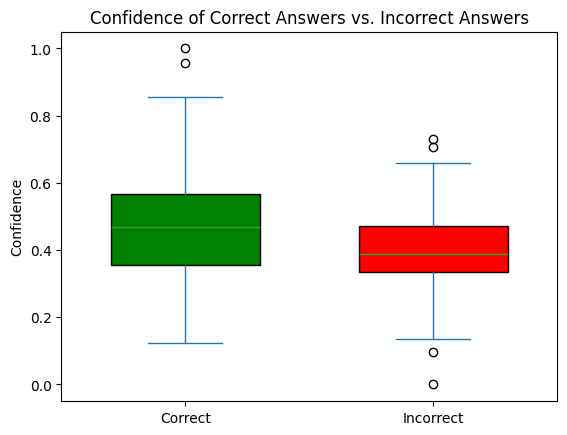

In [13]:
plot_conf(pred_df)

What about just the MCQ section? Perhaps the model underperforms on short answer questions.

In [25]:
mcq_df, cos_qn_mcq, cos_rp_mcq = get_predictions(
    qn_df, sd_df, true_topic_mcq, model=model
) 

evaluate_predictions(mcq_df, cos_qn_mcq, cos_rp_mcq)

--EVAL METRICS--
Exam-only accuracy: 60.00%
Report-only accuracy: 63.33%
The percent of time either the report or the exam labels a question correctly is 76.67%
True topic in top 3 report prediction 90.00%
True topic in top 3 question prediction 90.00%


Indeed, the model finds it easier to classify MCQ questions. Why?

In [12]:
pred_df.loc[30:].tail(10)

,label,text,comments,total_marks,pred_topic,pred_topic_idx,report_pred,true_topic_idx,true_topic
72,Question 8a.,student performed an experiment to compare the...,The first mark was awarded for recognising th...,4,Measuring changes in chemical reactions,1,3,3,Rates of chemical reactions
73,Question 8b.,student performed an experiment to compare the...,Any of the following: energy content / temper...,3,Measuring changes in chemical reactions,1,1,12,Investigation design
74,Question 8c.,student performed an experiment to compare the...,The first mark was awarded for the student re...,4,Measuring changes in chemical reactions,1,11,12,Investigation design
75,Question 8d.,student performed an experiment to compare the...,The first mark was awarded for the correct ca...,6,Measuring changes in chemical reactions,1,1,1,Measuring changes in chemical reactions
76,Question 8e.i.,student performed an experiment to compare the...,The first mark was awarded for correctly calc...,4,Measuring changes in chemical reactions,1,1,1,Measuring changes in chemical reactions
77,Question 8e.ii.,student performed an experiment to compare the...,The first mark was awarded for correctly stat...,4,Measuring changes in chemical reactions,1,11,11,How is scientific inquiry used to investigate ...
78,Question 8f.,student performed an experiment to compare the...,The first mark was awarded for correctly desc...,4,Measuring changes in chemical reactions,1,11,11,How is scientific inquiry used to investigate ...
79,Question 8g.,student performed an experiment to compare the...,Any response that referred correctly to the r...,3,Measuring changes in chemical reactions,1,11,11,How is scientific inquiry used to investigate ...
80,Question 9a.,Purified copper contains at least 99.8% copper...,The first mark was awarded for a correct defi...,7,Production of chemicals using electrolysis,5,5,5,Production of chemicals using electrolysis
81,Question 9b.,"Explain how the Faraday constant, together wit...",The first mark was awarded for the recognitio...,5,Production of chemicals using electrolysis,5,5,5,Production of chemicals using electrolysis


We can already see that this is probably a problem with how we chose to represent the question text that the model just cannot adapt to. For every subquestion, we chose to concatenate the text of the context. This is good in that it has a tendency to group subquestions together (which is a real pattern in examinations; subquestions often relate to each other), but the link seems to be too strong in that it also leads to erroneous homogeneity.

But without it, how would we ever classify part b) of a question whose only text is "Justify your answer"? 


On another note: Perhaps we can combine the model's predictions using the report and question in some way to models accuracy.
It should be noted that combining exam and report into one query to the model has been tried, but does not lead to increases in performance.

### Fine-tuning with SimCSE

SimCSE is an unsupervised learning algorithm that works by taking the same sentence twice, introducing dropout noise, then, based on the fact that these two features should be close together in embedding space, optimises a loss. 

We should see if we can improve the model by fine tuning it.

In [ ]:
from sentence_transformers import losses
from torch.utils.data import DataLoader
from sentence_transformers import InputExample

In [ ]:
training_exam_dfs = []
training_report_dfs = []

for exam_path in chem_dir.iterdir():
    if chem in str(exam_path):
        # leave current dataset for evaluation
        continue
    curr_exam = exam_path.stem
    train_exam_df, train_report_df, _ = prepare_dataframes(exam_path)
    train_exam_df.insert(0, "Exam Year", [curr_exam]*len(train_exam_df))
    train_report_df.insert(0, "Exam Year", [curr_exam]*len(train_report_df))

    training_exam_dfs.append(train_exam_df)
    training_report_dfs.append(train_report_df)

/home/ykip10/projects/Qlassifier/src/Qlassifier/fitting.py:61: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~(sd_df["label"].str.contains(


ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
# ["Exam Year", "Label"] unique for each year
training_ex_df = pd.concat(training_exam_dfs) \
                   .reset_index(drop=True) \
                   .drop_duplicates(subset=["Exam Year", "label"])

training_rp_df = pd.concat(training_report_dfs) \
                   .reset_index(drop=True) \
                   .rename({"comments": "text"}, axis=1) \
                   .fillna(value="")

ex_train_examples = [InputExample(texts=[s, s]) for s in training_ex_df["text"]]
rp_train_examples = [InputExample(texts=[s, s]) for s in training_rp_df["text"]]

ex_dataloader = DataLoader(ex_train_examples, shuffle=True, batch_size=32)

loss = losses.MultipleNegativesRankingLoss(model)
model.fit(train_objectives=[(ex_dataloader, loss)], epochs=1)

Step,Training Loss


In [ ]:
preds = get_mcq_predictions()

,label,text,input,predicted_topic,predicted_topic_idx,report_predict,true_topic_idx,true_topic
0,Question 1,Which one of the following correctly represent...,Which one of the following correctly represent...,Carbon-based fuels,0,0,0,Carbon-based fuels
1,Question 2,Which one of the following statements is corre...,Which one of the following statements is corre...,Primary galvanic cells and fuel cells as sourc...,2,2,2,Primary galvanic cells and fuel cells as sourc...
2,Question 3,"Molecules X, and all have the same number of c...","Molecules X, and all have the same number of c...","Structure, nomenclature and properties of orga...",6,6,6,"Structure, nomenclature and properties of orga..."
3,Question 4,cell can be considered secondary cell if A. it...,cell can be considered secondary cell if A. it...,Primary galvanic cells and fuel cells as sourc...,2,2,5,Production of chemicals using electrolysis
4,Question 5,Consider the following statements about coenzy...,Consider the following statements about coenzy...,Reactions of organic compounds,7,7,10,Medicinal chemistry
5,Question 6,Consider the following statements. I. HPLC is ...,Consider the following statements. I. HPLC is ...,Laboratory analysis of organic compounds,8,9,9,Instrumental analysis of organic compounds
6,Question 7,Consider the following statements about fossil...,Consider the following statements about fossil...,Carbon-based fuels,0,0,0,Carbon-based fuels
7,Question 8,"At 327 °C, the equilibrium constant for the re...","At 327 °C, the equilibrium constant for the re...",Extent of chemical reactions,4,4,4,Extent of chemical reactions
8,Question 9,Consider the following statements about coal s...,Consider the following statements about coal s...,Carbon-based fuels,0,0,0,Carbon-based fuels
9,Question 10,"At constant temperature, which one of the foll...","At constant temperature, which one of the foll...",Extent of chemical reactions,4,4,4,Extent of chemical reactions


The accuracy here is about 66% (I forgot to compute in python, I closed my IDE, do not want to re-train model).

Yeah so clearly our approach is wrong. It doesn't make sense to train the model to look for semantic similarities using SimCSE because two questions belonging to two different topics can be semantically similar (Such as "Calculate the ... of ..."), so an embedding space which doesn't bring together two similar topics doesn't help us.  

## Specialist Math

Next, I want to check how the model works on the specialist mathematics exams. Without customising, for the same reason as above.

Let's just use the same model and approach. We learnt that there's really no benefit to fine-tuning (on this model, for this task, with our data), so we won't waste time doing that. 

In [26]:
mcq_labels = [
    0, 1, 1, 2, 2, 4, 4, 4, 7, 3, 
    3, 5, 5, 6, 6, 8, 6, 7, 9, 11,
]

ground_truth = mcq_labels + [
    1, 3, 3, 3, 7, 8, 3, 3,            # Q1
    2, 2, 2, 2, 2, 2, 2, 2,            # Q2
    3, 3, 3, 3, 3, 3,                  # Q3
    4, 4, 4, 4, 4, 4, 1, 4,            # Q4
    6, 6, 7, 7, 7, 7,                  # Q5
    11, 11, 11, 12, 12, 12, 12, 12, 10 # Q6  

]

qn_df_math, sd_df_math = prepare_dataframes(math_path)
pred_df_math, cos_qn_math, cos_rp_math  = get_predictions(
    qn_df_math, sd_df_math, labels=ground_truth, model=model
)

In [27]:
evaluate_predictions(pred_df_math, cos_qn_math, cos_rp_math)

--EVAL METRICS--
Exam-only accuracy: 52.31%
Report-only accuracy: 16.92%
The percent of time either the report or the exam labels a question correctly is 55.38%
True topic in top 3 report prediction 33.85%
True topic in top 3 question prediction 80.00%


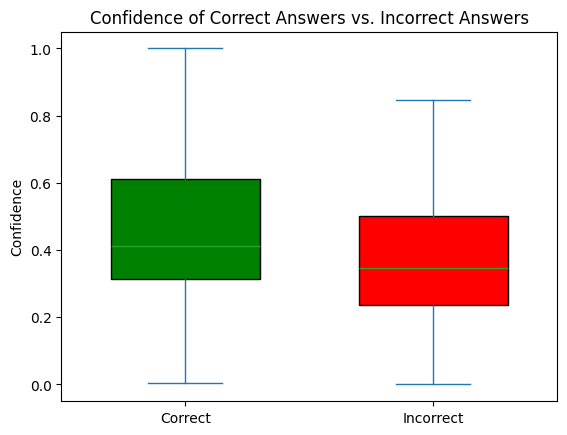

In [29]:
plot_conf(pred_df_math)

Check MCQ only performance

In [28]:
mcq_df_math, cos_qn_math_mcq, cos_rp_math_mcq  = get_predictions(
    qn_df_math, sd_df_math, labels=mcq_labels, model=model
)

evaluate_predictions(mcq_df_math, cos_qn_math_mcq, cos_rp_math_mcq)

--EVAL METRICS--
Exam-only accuracy: 70.00%
Report-only accuracy: 10.00%
The percent of time either the report or the exam labels a question correctly is 70.00%
True topic in top 3 report prediction 35.00%
True topic in top 3 question prediction 85.00%


The report comments are mostly empty for these mcq questions. We note that if this is the case, the report's predictions should be weighed very lightly. For the chemistry case, where the report text is dense, the reports seem to capture some patterns uncaptured by the exam questions.

Also, we learnt that this model actually performs substantially better in the mathematics (at least on this limited, small mcq only dataset) when compared to the TF-IDF approach (although still not great).

# Instructor

## Chem

In [ ]:
pred_df, cos_qn, cos_rp  = get_predictions(
    qn_df, sd_df, labels=true_topic_indices, model=model2, subject="Chemistry", instruct=True
)
pred_df.head(5)

`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.


,label,text,comments,total_marks,pred_topic,pred_topic_idx,report_pred,true_topic_idx,true_topic
0,Question 1,Which one of the following correctly represent...,"In human cells, glucose reacts with oxygen in ...",1,Carbon-based fuels,0,0,0,Carbon-based fuels
1,Question 2,Which one of the following statements is corre...,Fuel cells and galvanic cells both produce hea...,1,Primary galvanic cells and fuel cells as sourc...,2,2,2,Primary galvanic cells and fuel cells as sourc...
2,Question 3,"Molecules X, and all have the same number of c...",The larger the number of C=C double bonds in t...,1,"Structure, nomenclature and properties of orga...",6,6,6,"Structure, nomenclature and properties of orga..."
3,Question 4,cell can be considered secondary cell if A. it...,The polarity of the physical electrodes does n...,1,Primary galvanic cells and fuel cells as sourc...,2,2,5,Production of chemicals using electrolysis
4,Question 5,Consider the following statements about coenzy...,All three statements are properties of coenzym...,1,Rates of chemical reactions,3,3,10,Medicinal chemistry


In [ ]:
evaluate_predictions(pred_df, cos_qn, cos_rp)

--EVAL METRICS--
Exam-only accuracy: 47.56%
Report-only accuracy: 47.56%
The percent of time either the report or the exam labels a question correctly is 63.41%
True topic in top 3 question prediction 79.27%
True topic in top 3 report prediction 81.71%


This model does perform slightly better on the short answer. What about MCQ?

In [ ]:
mcq_df, cos_qn_mcq, cos_rp_mcq = get_predictions(
    qn_df, sd_df, labels=true_topic_mcq, model=model2, subject="Chemistry", instruct=True
) 
evaluate_predictions(mcq_df, cos_qn_mcq, cos_rp_mcq)

`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.


--EVAL METRICS--
Exam-only accuracy: 66.67%
Report-only accuracy: 63.33%
The percent of time either the report or the exam labels a question correctly is 73.33%
True topic in top 3 question prediction 93.33%
True topic in top 3 report prediction 93.33%


Marginal improvements, if any. 

## Math

In [ ]:
pred_df_math, cos_qn_math, cos_rp_math  = get_predictions(
    qn_df_math, sd_df_math, labels=ground_truth, model=model2, subject="Mathematics", instruct=True
)

`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.


In [ ]:
evaluate_predictions(pred_df_math, cos_qn_math, cos_rp_math)

--EVAL METRICS--
Exam-only accuracy: 81.54%
Report-only accuracy: 18.46%
The percent of time either the report or the exam labels a question correctly is 83.08%
True topic in top 3 question prediction 93.85%
True topic in top 3 report prediction 41.54%


These are quite massive improvements over the previous model. And the MCQ section in particular?

In [ ]:
mcq_df_math, cos_qn_math_mcq, cos_rp_math_mcq  = get_predictions(
    qn_df_math, sd_df_math, labels=mcq_labels, model=model2, subject="Mathematics", instruct=True
)

evaluate_predictions(mcq_df_math, cos_qn_math_mcq, cos_rp_math_mcq)

`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.
`SentenceTransformer._target_device` has been deprecated, please use `SentenceTransformer.device` instead.


--EVAL METRICS--
Exam-only accuracy: 75.00%
Report-only accuracy: 10.00%
The percent of time either the report or the exam labels a question correctly is 75.00%
True topic in top 3 question prediction 100.00%
True topic in top 3 report prediction 30.00%


The MCQ section improved as well, but its the short answer questions which have been massively improved.

In [ ]:
mcq_df_math.to_csv("model2_math.csv")
mcq_df.to_csv("model2_chem.csv")

The instructor model performs far better for mathematics than the purely sentence-transformer one.